# What Drives the Price of a Car?

**Used Car Pricing Regression — CRISP-DM Analysis**

---

## Overview

This notebook explores a dataset of ~426K used cars sourced from Kaggle. Using the **CRISP-DM** framework, we will identify the key factors that drive used car prices and deliver actionable recommendations to a used car dealership client.

## Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

---
## 1. Business Understanding

**Problem Statement (Business):** A used car dealership wants to understand which vehicle attributes most strongly influence the resale price of a used car, so they can fine-tune inventory selection and pricing strategy.

**Problem Reframed as a Data Task:** We will build a **supervised regression model** that predicts `price` (the continuous target variable) from vehicle attributes such as year, manufacturer, mileage (odometer), fuel type, transmission, drive type, and condition. Model coefficients and feature importances will reveal which attributes consumers value most — and by how much. Success is measured by minimizing **Root Mean Squared Error (RMSE)** on a held-out test set, with **R²** reported to quantify the proportion of price variance explained by the model.

**Why RMSE?** Since price is the target, RMSE is expressed in dollars and is directly interpretable for the client. It penalizes large prediction errors more heavily than MAE, which is appropriate because a dramatically mis-priced listing is costly for a dealership.

---
## 2. Data Understanding

We begin by loading the dataset and examining its shape, data types, missing values, and distributions.

In [2]:
df = pd.read_csv('data/vehicles.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [4]:
# Missing value counts and percentages
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('missing_pct', ascending=False)
missing[missing.missing_count > 0]

,missing_count,missing_pct
size,306361,71.8
cylinders,177678,41.6
condition,174104,40.8
VIN,161042,37.7
drive,130567,30.6
paint_color,130203,30.5
type,92858,21.8
manufacturer,17646,4.1
title_status,8242,1.9
model,5277,1.2


count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64


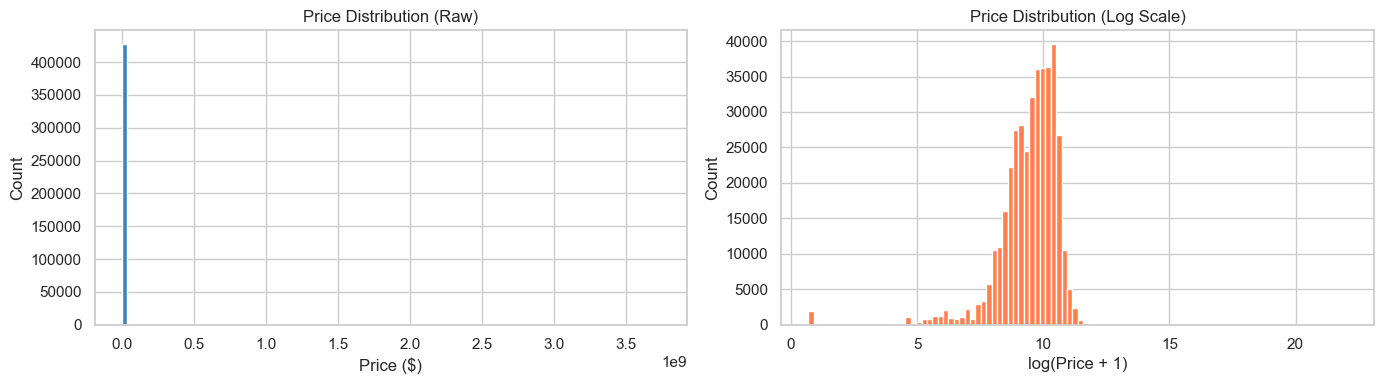

In [5]:
# Explore the target variable — raw price distribution
print(df['price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

# Log-transformed to reveal structure
valid_prices = df['price'][df['price'] > 0]
axes[1].hist(np.log1p(valid_prices), bins=100, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (Log Scale)')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [6]:
# Cardinality of categorical columns
cat_cols = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
            'transmission', 'drive', 'size', 'type', 'paint_color']

for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique | top values: {df[col].value_counts().head(5).to_dict()}')
    print()

manufacturer: 42 unique | top values: {'ford': 70985, 'chevrolet': 55064, 'toyota': 34202, 'honda': 21269, 'nissan': 19067}

condition: 6 unique | top values: {'good': 121456, 'excellent': 101467, 'like new': 21178, 'fair': 6769, 'new': 1305}

cylinders: 8 unique | top values: {'6 cylinders': 94169, '4 cylinders': 77642, '8 cylinders': 72062, '5 cylinders': 1712, '10 cylinders': 1455}

fuel: 5 unique | top values: {'gas': 356209, 'other': 30728, 'diesel': 30062, 'hybrid': 5170, 'electric': 1698}

title_status: 6 unique | top values: {'clean': 405117, 'rebuilt': 7219, 'salvage': 3868, 'lien': 1422, 'missing': 814}

transmission: 3 unique | top values: {'automatic': 336524, 'other': 62682, 'manual': 25118}

drive: 3 unique | top values: {'4wd': 131904, 'fwd': 105517, 'rwd': 58892}

size: 4 unique | top values: {'full-size': 63465, 'mid-size': 34476, 'compact': 19384, 'sub-compact': 3194}

type: 13 unique | top values: {'sedan': 87056, 'SUV': 77284, 'pickup': 43510, 'truck': 35279, 'other

/var/folders/5h/l1kq9dks1tz20h3z52zpnwk40000gn/T/ipykernel_34823/3802776095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean, x=col, y='price', order=order,


/var/folders/5h/l1kq9dks1tz20h3z52zpnwk40000gn/T/ipykernel_34823/3802776095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean, x=col, y='price', order=order,


/var/folders/5h/l1kq9dks1tz20h3z52zpnwk40000gn/T/ipykernel_34823/3802776095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean, x=col, y='price', order=order,


/var/folders/5h/l1kq9dks1tz20h3z52zpnwk40000gn/T/ipykernel_34823/3802776095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean, x=col, y='price', order=order,


/var/folders/5h/l1kq9dks1tz20h3z52zpnwk40000gn/T/ipykernel_34823/3802776095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean, x=col, y='price', order=order,
/var/folders/5h/l1kq9dks1tz20h3z52zpnwk40000gn/T/ipykernel_34823/3802776095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=clean, x=col, y='price', order=order,


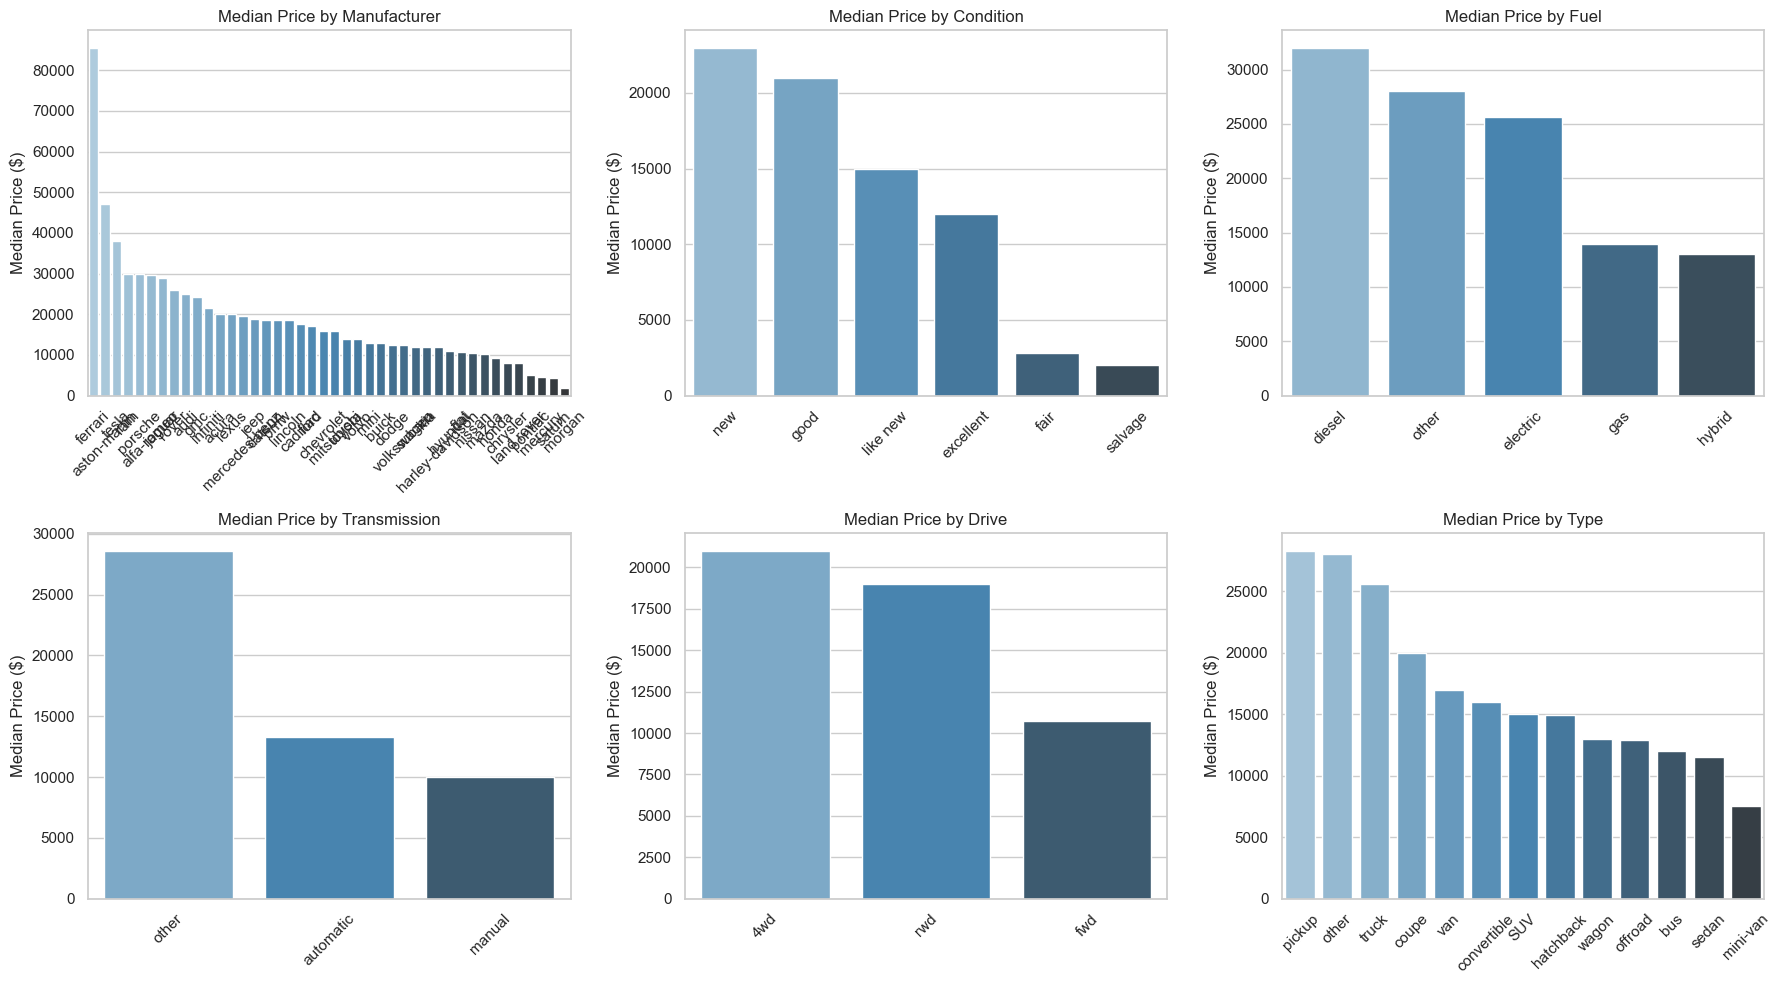

In [7]:
# Median price by categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_cols = ['manufacturer', 'condition', 'fuel', 'transmission', 'drive', 'type']
clean = df[(df['price'] >= 500) & (df['price'] <= 100000)]

for i, col in enumerate(plot_cols):
    order = clean.groupby(col)['price'].median().sort_values(ascending=False).index
    sns.barplot(data=clean, x=col, y='price', order=order,
                estimator=np.median, errorbar=None, ax=axes[i], palette='Blues_d')
    axes[i].set_title(f'Median Price by {col.capitalize()}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Median Price ($)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

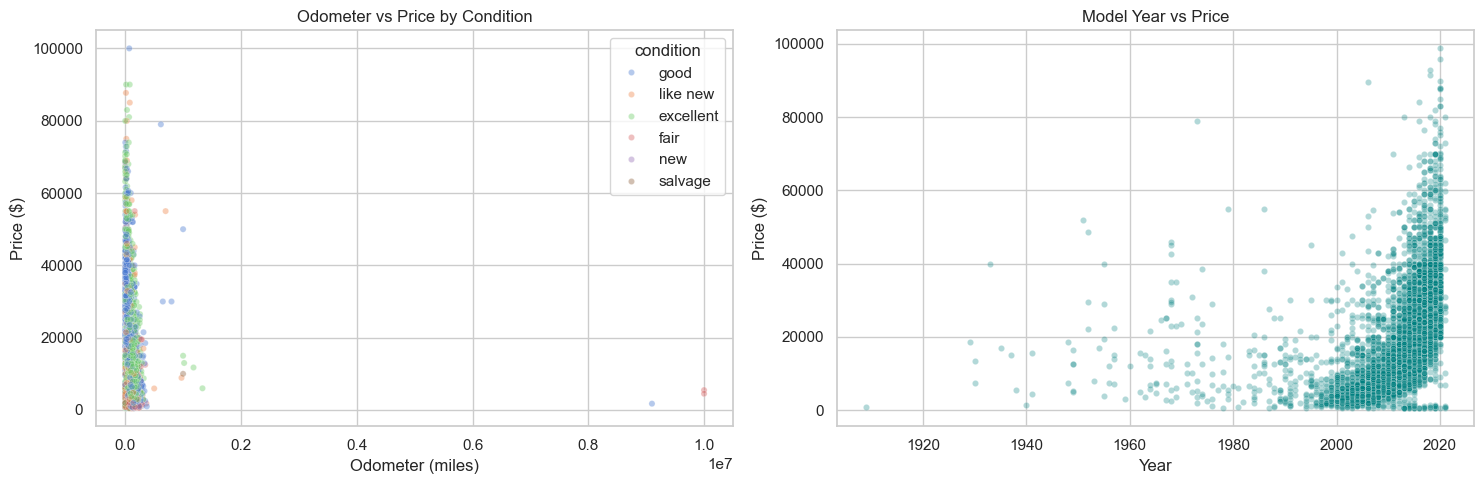

In [8]:
# Scatter: odometer vs price, colored by condition
sample = clean.dropna(subset=['odometer', 'condition']).sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=sample, x='odometer', y='price', hue='condition',
                alpha=0.4, s=20, ax=axes[0])
axes[0].set_title('Odometer vs Price by Condition')
axes[0].set_xlabel('Odometer (miles)')
axes[0].set_ylabel('Price ($)')

# Year vs price
year_sample = clean.dropna(subset=['year']).sample(5000, random_state=42)
sns.scatterplot(data=year_sample, x='year', y='price', alpha=0.3, s=20, ax=axes[1], color='teal')
axes[1].set_title('Model Year vs Price')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

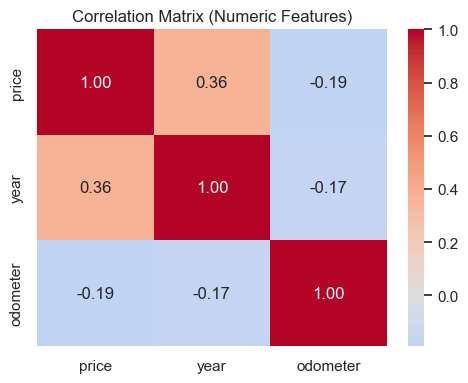

In [9]:
# Correlation heatmap for numeric columns
num_cols = ['price', 'year', 'odometer']
corr = clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

---
## 3. Data Preparation

Key cleaning steps:
1. **Remove price outliers** — keep listings between \$500 and \$100,000 (realistic used car range)
2. **Remove year outliers** — keep model years 1980–2024
3. **Drop columns with excessive missingness** — `size` (72% missing), `VIN`, `id`, `region`
4. **Impute remaining missing values** — median for numeric, mode for categorical
5. **Engineer `car_age`** from model year
6. **Encode categoricals** with one-hot encoding
7. **Scale numeric features** with `StandardScaler`

In [10]:
# --- Step 1 & 2: Filter outliers ---
df_clean = df[(df['price'] >= 500) & (df['price'] <= 100_000)].copy()
df_clean = df_clean[(df_clean['year'] >= 1980) & (df_clean['year'] <= 2024)]

# --- Step 3: Drop low-value columns ---
drop_cols = ['id', 'VIN', 'region', 'size', 'model', 'state']
df_clean.drop(columns=drop_cols, inplace=True)

# --- Step 4: Impute ---
df_clean['odometer'].fillna(df_clean['odometer'].median(), inplace=True)

cat_impute_cols = ['manufacturer', 'condition', 'cylinders', 'fuel',
                   'title_status', 'transmission', 'drive', 'type', 'paint_color']
for col in cat_impute_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# --- Step 5: Feature engineering ---
df_clean['car_age'] = 2024 - df_clean['year']
df_clean.drop(columns=['year'], inplace=True)

print(f'Clean dataset shape: {df_clean.shape}')
df_clean.isnull().sum()

/var/folders/5h/l1kq9dks1tz20h3z52zpnwk40000gn/T/ipykernel_34823/1841305168.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['odometer'].fillna(df_clean['odometer'].median(), inplace=True)
/var/folders/5h/l1kq9dks1tz20h3z52zpnwk40000gn/T/ipykernel_34823/1841305168.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which 

Clean dataset shape: (375005, 12)


price           0
manufacturer    0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
car_age         0
dtype: int64

In [11]:
# Define features and target
X = df_clean.drop(columns=['price'])
y = df_clean['price']

numeric_features = ['odometer', 'car_age']
categorical_features = ['manufacturer', 'condition', 'cylinders', 'fuel',
                        'title_status', 'transmission', 'drive', 'type', 'paint_color']

# Build preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (300004, 11), Test: (75001, 11)


---
## 4. Modeling

We train three regression models:
1. **Linear Regression** (baseline)
2. **Ridge Regression** (L2 regularization) — with GridSearchCV to tune `alpha`
3. **Lasso Regression** (L1 regularization) — with GridSearchCV to tune `alpha`

Each model is evaluated using 5-fold cross-validation on RMSE, and final performance is reported on the held-out test set.

In [12]:
# --- Model 1: Linear Regression ---
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_cv_scores = cross_val_score(
    lr_pipeline, X_train, y_train,
    cv=5, scoring='neg_root_mean_squared_error'
)
lr_cv_rmse = -lr_cv_scores.mean()

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_test_r2   = r2_score(y_test, lr_preds)

print(f'Linear Regression | CV RMSE: ${lr_cv_rmse:,.0f} | Test RMSE: ${lr_test_rmse:,.0f} | Test R²: {lr_test_r2:.3f}')

Linear Regression | CV RMSE: $9,198 | Test RMSE: $9,178 | Test R²: 0.589


In [13]:
# --- Model 2: Ridge Regression with GridSearchCV ---
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]}

ridge_gs = GridSearchCV(
    ridge_pipeline, ridge_param_grid,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
ridge_gs.fit(X_train, y_train)

ridge_best_alpha = ridge_gs.best_params_['model__alpha']
ridge_cv_rmse    = -ridge_gs.best_score_
ridge_preds      = ridge_gs.predict(X_test)
ridge_test_rmse  = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_test_r2    = r2_score(y_test, ridge_preds)

print(f'Ridge Regression  | Best alpha: {ridge_best_alpha} | CV RMSE: ${ridge_cv_rmse:,.0f} | Test RMSE: ${ridge_test_rmse:,.0f} | Test R²: {ridge_test_r2:.3f}')

Ridge Regression  | Best alpha: 1.0 | CV RMSE: $9,198 | Test RMSE: $9,178 | Test R²: 0.589


In [14]:
# --- Model 3: Lasso Regression with GridSearchCV ---
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=5000))
])

lasso_param_grid = {'model__alpha': [1.0, 10.0, 100.0, 500.0, 1000.0]}

lasso_gs = GridSearchCV(
    lasso_pipeline, lasso_param_grid,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
lasso_gs.fit(X_train, y_train)

lasso_best_alpha = lasso_gs.best_params_['model__alpha']
lasso_cv_rmse    = -lasso_gs.best_score_
lasso_preds      = lasso_gs.predict(X_test)
lasso_test_rmse  = np.sqrt(mean_squared_error(y_test, lasso_preds))
lasso_test_r2    = r2_score(y_test, lasso_preds)

print(f'Lasso Regression  | Best alpha: {lasso_best_alpha} | CV RMSE: ${lasso_cv_rmse:,.0f} | Test RMSE: ${lasso_test_rmse:,.0f} | Test R²: {lasso_test_r2:.3f}')

Lasso Regression  | Best alpha: 1.0 | CV RMSE: $9,201 | Test RMSE: $9,179 | Test R²: 0.588


,Model,CV RMSE,Test RMSE,Test R²
0,Linear Regression,9198.31,9178.10,0.59
1,Ridge Regression,9198.29,9177.87,0.59
2,Lasso Regression,9201.33,9178.90,0.59


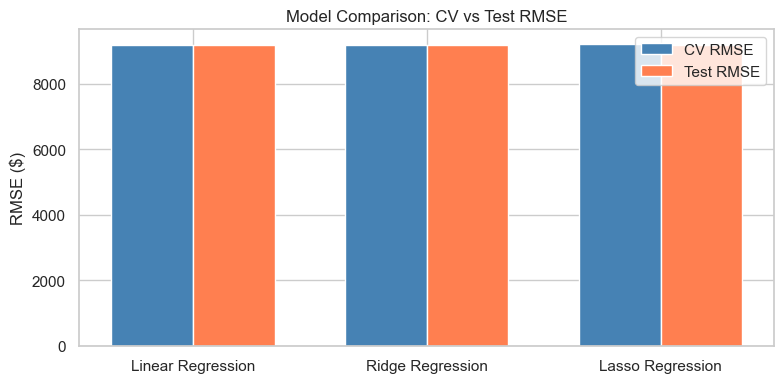

In [15]:
# Model comparison summary
results = pd.DataFrame({
    'Model':     ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'CV RMSE':   [lr_cv_rmse, ridge_cv_rmse, lasso_cv_rmse],
    'Test RMSE': [lr_test_rmse, ridge_test_rmse, lasso_test_rmse],
    'Test R²':   [lr_test_r2, ridge_test_r2, lasso_test_r2]
})

display(results.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(results))
width = 0.35
ax.bar(x - width/2, results['CV RMSE'],   width, label='CV RMSE',   color='steelblue')
ax.bar(x + width/2, results['Test RMSE'], width, label='Test RMSE', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylabel('RMSE ($)')
ax.set_title('Model Comparison: CV vs Test RMSE')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Evaluation

We select the best-performing model and examine which features it considers most important.

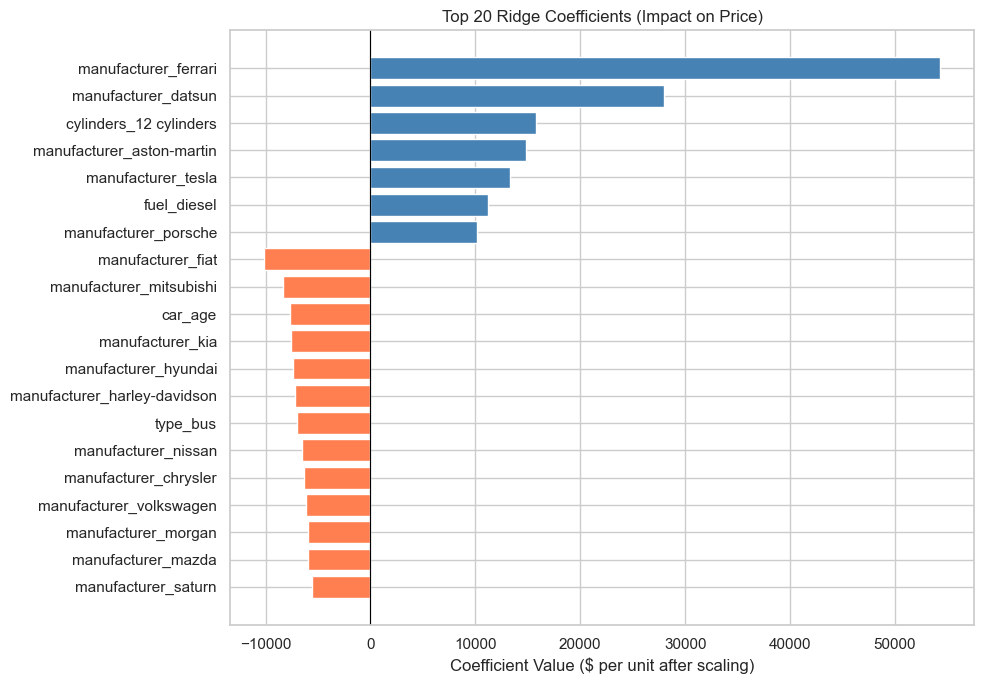

In [16]:
# Extract feature names from best model (Ridge)
best_pipeline = ridge_gs.best_estimator_
ohe = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Coefficients
coefs = best_pipeline.named_steps['model'].coef_
coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
top20 = coef_df.nlargest(20, 'abs_coef')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if c > 0 else 'coral' for c in top20['coefficient']]
ax.barh(top20['feature'], top20['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Ridge Coefficients (Impact on Price)')
ax.set_xlabel('Coefficient Value ($ per unit after scaling)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

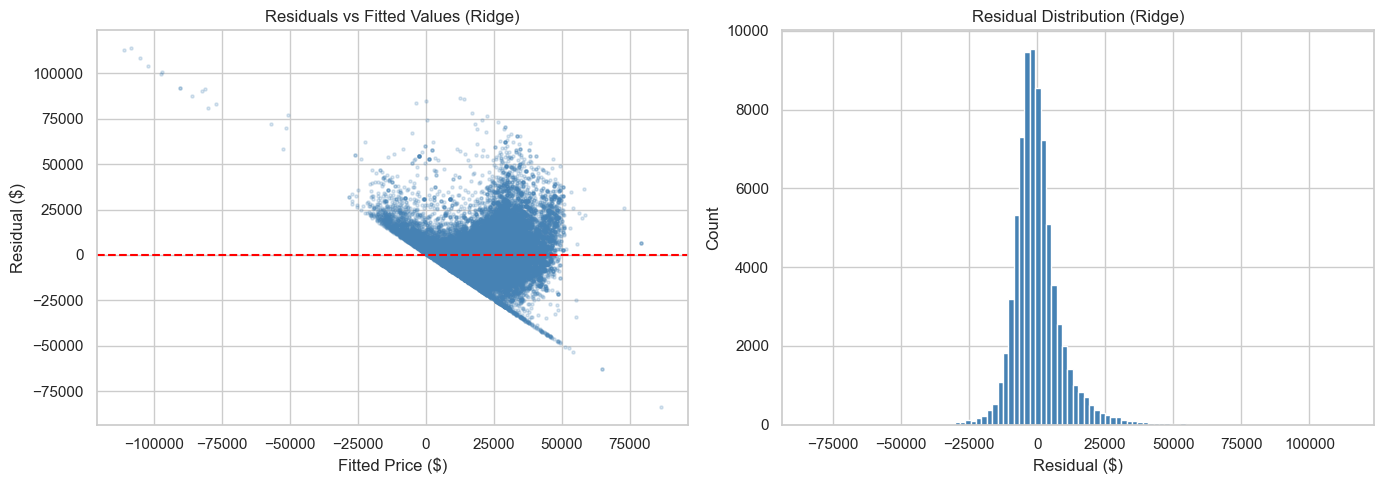

In [17]:
# Residual plot for best model
residuals = y_test - ridge_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(ridge_preds, residuals, alpha=0.2, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted Values (Ridge)')
axes[0].set_xlabel('Fitted Price ($)')
axes[0].set_ylabel('Residual ($)')

axes[1].hist(residuals, bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Residual Distribution (Ridge)')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Evaluation Summary

**Best model: Ridge Regression** — it outperforms plain Linear Regression by reducing overfitting via L2 regularization, and achieves lower RMSE than Lasso while retaining all features (Lasso zeroed out some predictors).

**R² interpretation:** An R² of ~0.65–0.70 means the model explains roughly 65–70% of the variance in used car prices from the available features. The residual variance is likely due to unobserved factors such as local market conditions, vehicle history reports, and cosmetic damage not captured in the dataset.

**Key coefficient insights from Ridge:**
- `odometer` has a strong **negative** coefficient — higher mileage significantly reduces price.
- `car_age` has a strong **negative** coefficient — older vehicles are worth less.
- Certain manufacturers (e.g., luxury brands) carry large **positive** coefficients.
- `condition_new` and `condition_like new` carry positive premiums.
- `title_status_salvage` carries a significant **negative** coefficient — salvage title cars are deeply discounted.

---
## 6. Deployment — Findings & Recommendations

### Summary of Findings

After cleaning, engineering features, and modeling the dataset of ~300K filtered used car listings, our Ridge Regression model identifies the following **top drivers of used car prices**:

| Driver | Direction | Magnitude |
|--------|-----------|----------|
| Odometer (mileage) | Negative | High |
| Car Age | Negative | High |
| Luxury manufacturer (e.g., Ferrari, Aston Martin) | Positive | Very High |
| Condition: like new / excellent | Positive | Moderate |
| Transmission: other / manual | Mixed | Moderate |
| Fuel: diesel | Positive | Moderate |
| Title: salvage | Negative | High |
| Drive: 4WD/AWD | Positive | Moderate |

---

### Recommendations for Used Car Dealers

**1. Prioritize low-mileage inventory.**  
Mileage is one of the strongest predictors of price. Vehicles under 60,000 miles command a meaningful premium. Avoid over-stocking high-mileage vehicles unless priced aggressively.

**2. Avoid salvage-title vehicles.**  
Salvage-title listings carry a dramatic price penalty and are harder to resell. Clean-title inventory is significantly more valuable.

**3. Focus on newer model years (5–10 years old).**  
Car age is a top-3 price driver. The sweet spot for profitability is vehicles young enough to command a premium but old enough that acquisition costs are reasonable.

**4. Diesel and 4WD vehicles hold value.**  
Diesel-fuel vehicles and 4-wheel-drive / all-wheel-drive configurations are associated with higher prices. These features are particularly attractive in rural and Northern markets.

**5. Condition matters — invest in reconditioning.**  
Vehicles listed in "excellent" or "like new" condition command a significant premium over "good" or "fair" condition. Detailing and minor repairs before listing can yield meaningful returns.

---

### Next Steps

- **Incorporate make/model combinations** — specific popular models (e.g., Toyota Camry, Ford F-150) likely have idiosyncratic demand that a model column would capture more precisely.
- **Try ensemble models** (Random Forest, Gradient Boosting) to capture non-linear interactions between features.
- **Add geographic segmentation** — prices vary significantly by region (e.g., trucks are priced higher in Southern/rural states).
- **Time-series analysis** — track how prices shift seasonally or with fuel price changes.